<a href="https://colab.research.google.com/github/dhivyamohan92/Taxi-Data-Analysis-Visualization-Using-Python/blob/main/data_visualization_using_phython_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [4]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [9]:
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


In [10]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


For categorical columns, it's common practice to replace null values with the column's mode (most frequent value), as a 'mean' is not applicable. I'll apply this to `payment`, `pickup_zone`, `dropoff_zone`, `pickup_borough`, and `dropoff_borough`.

In [11]:
# Fill null values in 'payment' with its mode
mode_payment = df['payment'].mode()[0]
df['payment'].fillna(mode_payment, inplace=True)

# Fill null values in other categorical columns with their respective modes
columns_to_fill_mode = ['pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

for col in columns_to_fill_mode:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

print("Null values after imputation:")
display(df.isnull().sum())

Null values after imputation:


/tmp/ipykernel_789/2401028655.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['payment'].fillna(mode_payment, inplace=True)
/tmp/ipykernel_789/2401028655.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


Another way to fill null values with the mode, without an explicit `for` loop, is to use the `apply` method on the selected columns. This can be more concise.

In [12]:
# First, let's reload the dataset to reset the changes from the previous imputation
# This ensures we are working with the original null values for demonstration purposes
df_alt = sns.load_dataset("taxis")

# Fill null values in 'payment' with its mode using fillna directly
mode_payment = df_alt['payment'].mode()[0]
df_alt['payment'].fillna(mode_payment, inplace=True)

# Define the columns to fill with their respective modes
columns_to_fill_mode_alt = ['pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

# Use apply with a lambda function to fill nulls with mode for the specified columns
df_alt[columns_to_fill_mode_alt] = df_alt[columns_to_fill_mode_alt].apply(lambda x: x.fillna(x.mode()[0]))

print("Null values after imputation (using apply method):")
display(df_alt.isnull().sum())

Null values after imputation (using apply method):


/tmp/ipykernel_789/3302152196.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_alt['payment'].fillna(mode_payment, inplace=True)


,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


In [14]:
import pandas as pd
df["pickup"]=pd.to_datetime(df["pickup"])
df["pickup"]

,pickup
0,2019-03-23 20:21:09
1,2019-03-04 16:11:55
2,2019-03-27 17:53:01
3,2019-03-10 01:23:59
4,2019-03-30 13:27:42
...,...
6428,2019-03-31 09:51:53
6429,2019-03-31 17:38:00
6430,2019-03-23 22:55:18
6431,2019-03-04 10:09:25


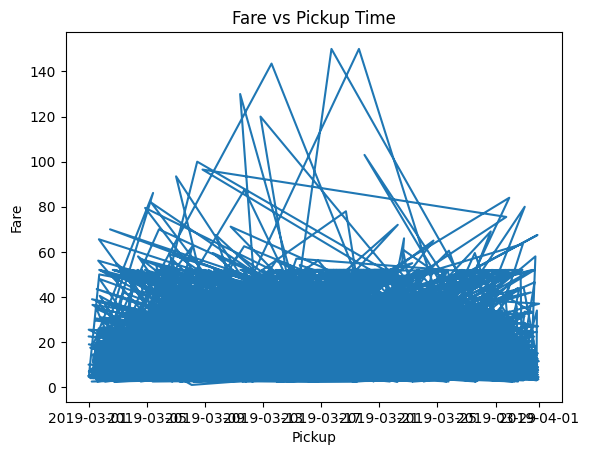

In [17]:
plt.plot(df["pickup"],df["fare"])
plt.title("Fare vs Pickup Time")
plt.xlabel("Pickup")
plt.ylabel("Fare")
plt.show()

In [18]:
df['month'] = df['pickup'].dt.month

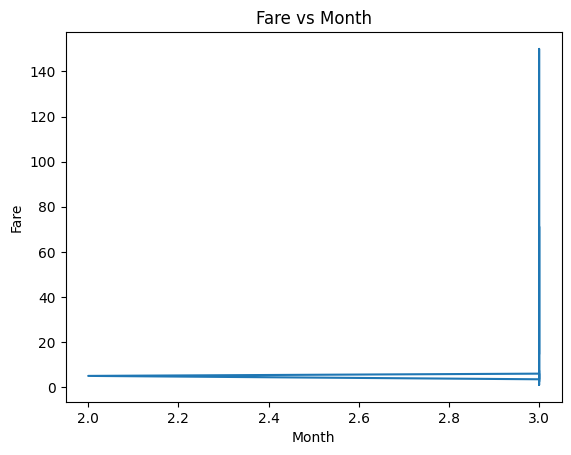

In [19]:
plt.plot(df['month'], df['fare'])
plt.title("Fare vs Month")
plt.xlabel("Month")
plt.ylabel("Fare")
plt.show()

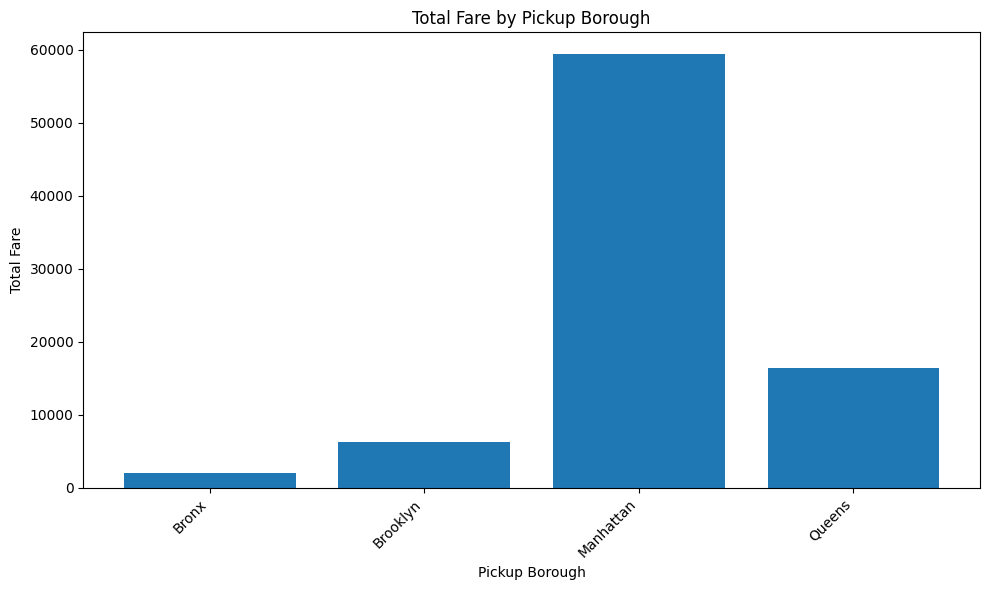

In [21]:
import matplotlib.pyplot as plt

total_fare_by_borough = df.groupby('pickup_borough')['fare'].sum().reset_index()

plt.figure(figsize=(10, 6))

plt.bar(
    total_fare_by_borough['pickup_borough'],
    total_fare_by_borough['fare']
)

plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

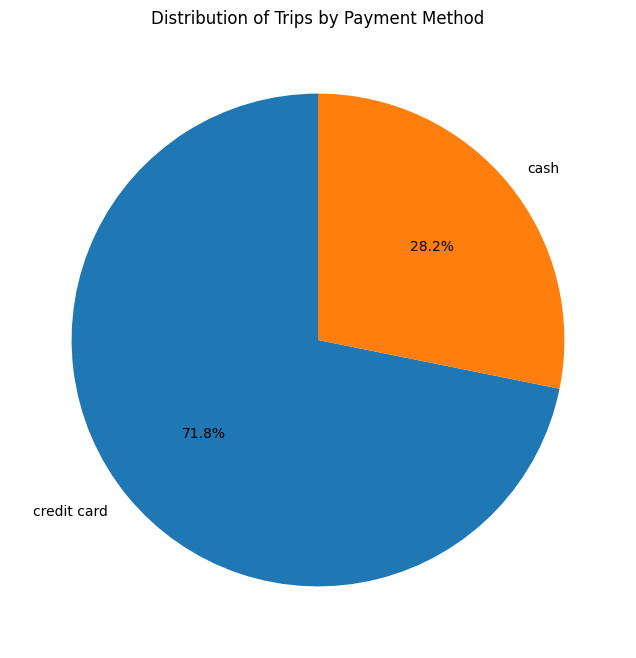

In [24]:
payment_counts = df['payment'].value_counts()
payment_counts
plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Trips by Payment Method')

plt.show()

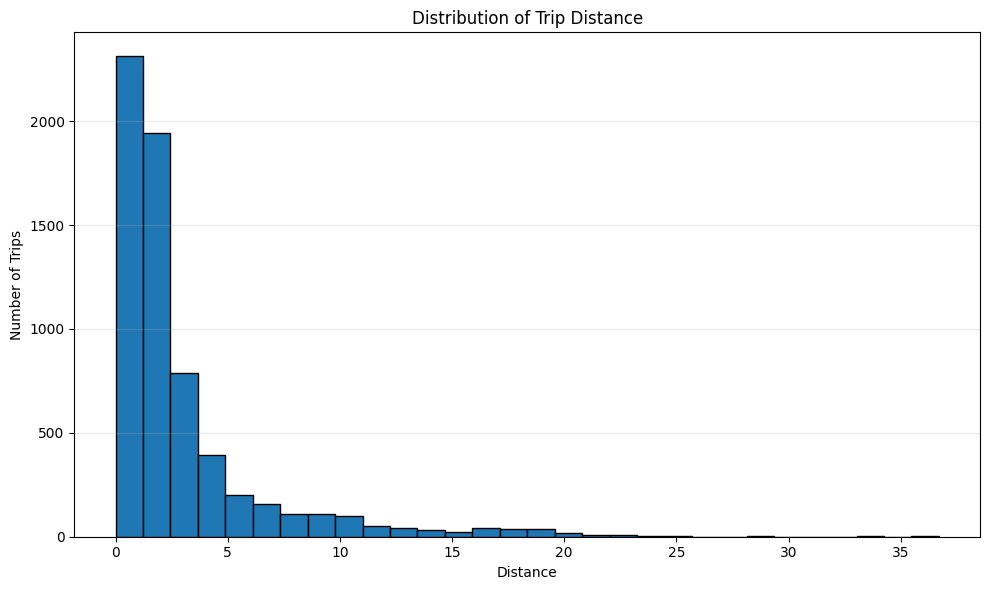

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['distance'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Trip Distance')
plt.xlabel('Distance')
plt.ylabel('Number of Trips')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

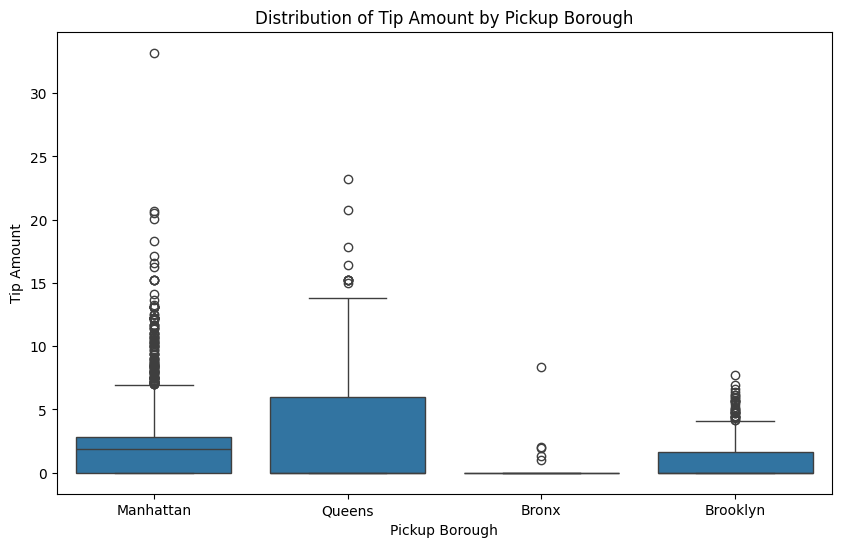

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='pickup_borough',
    y='tip',
    data=df
)

plt.title('Distribution of Tip Amount by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')

plt.show()

/tmp/ipykernel_789/485251933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_borough', data=df, palette='viridis')


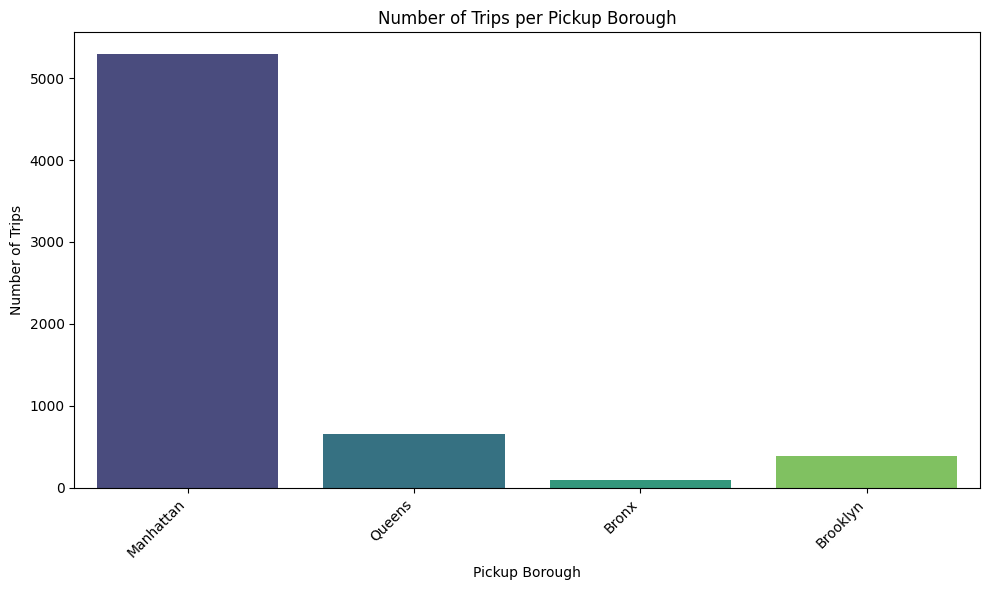

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_borough', data=df, palette='viridis')
plt.title('Number of Trips per Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

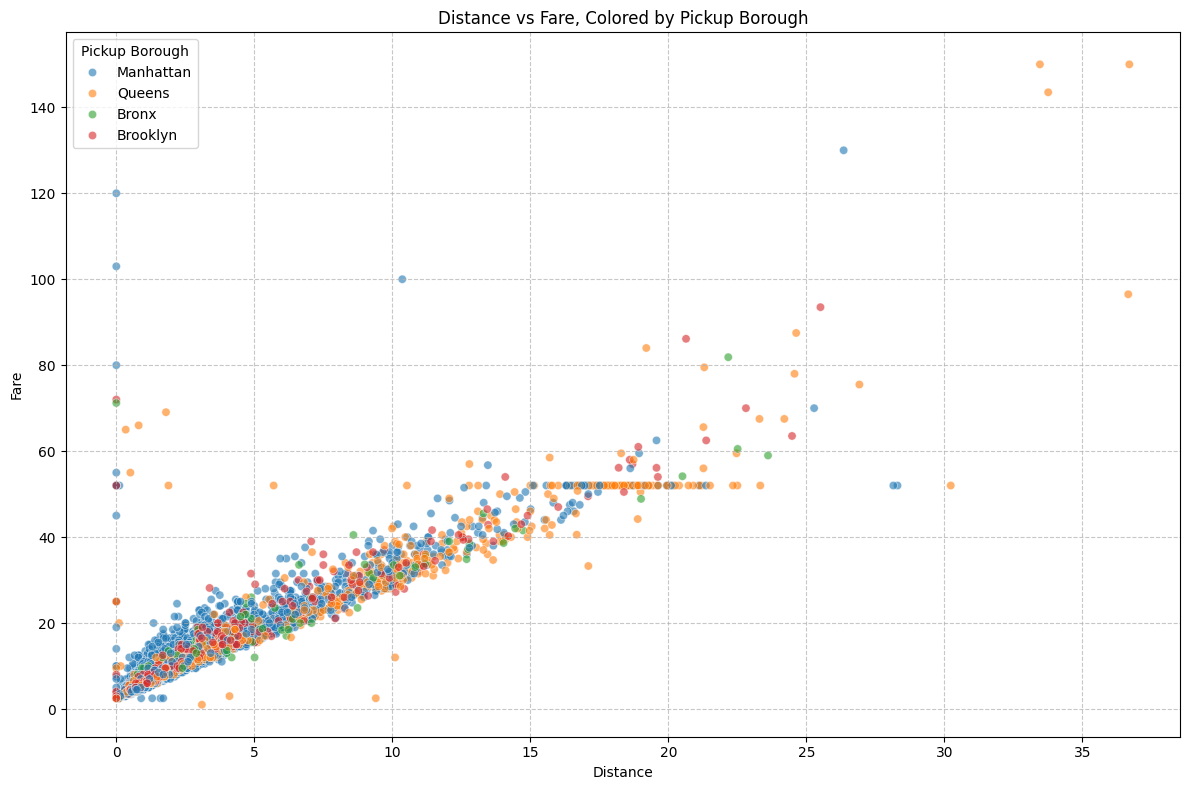

In [29]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df, alpha=0.6)
plt.title('Distance vs Fare, Colored by Pickup Borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.legend(title='Pickup Borough')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

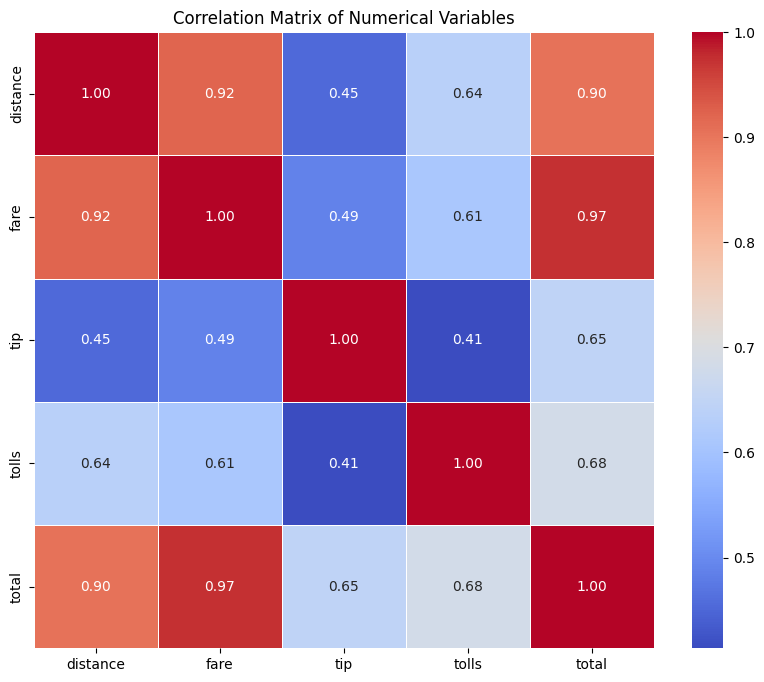

In [30]:
numerical_cols = ['distance', 'fare', 'tip', 'tolls', 'total']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

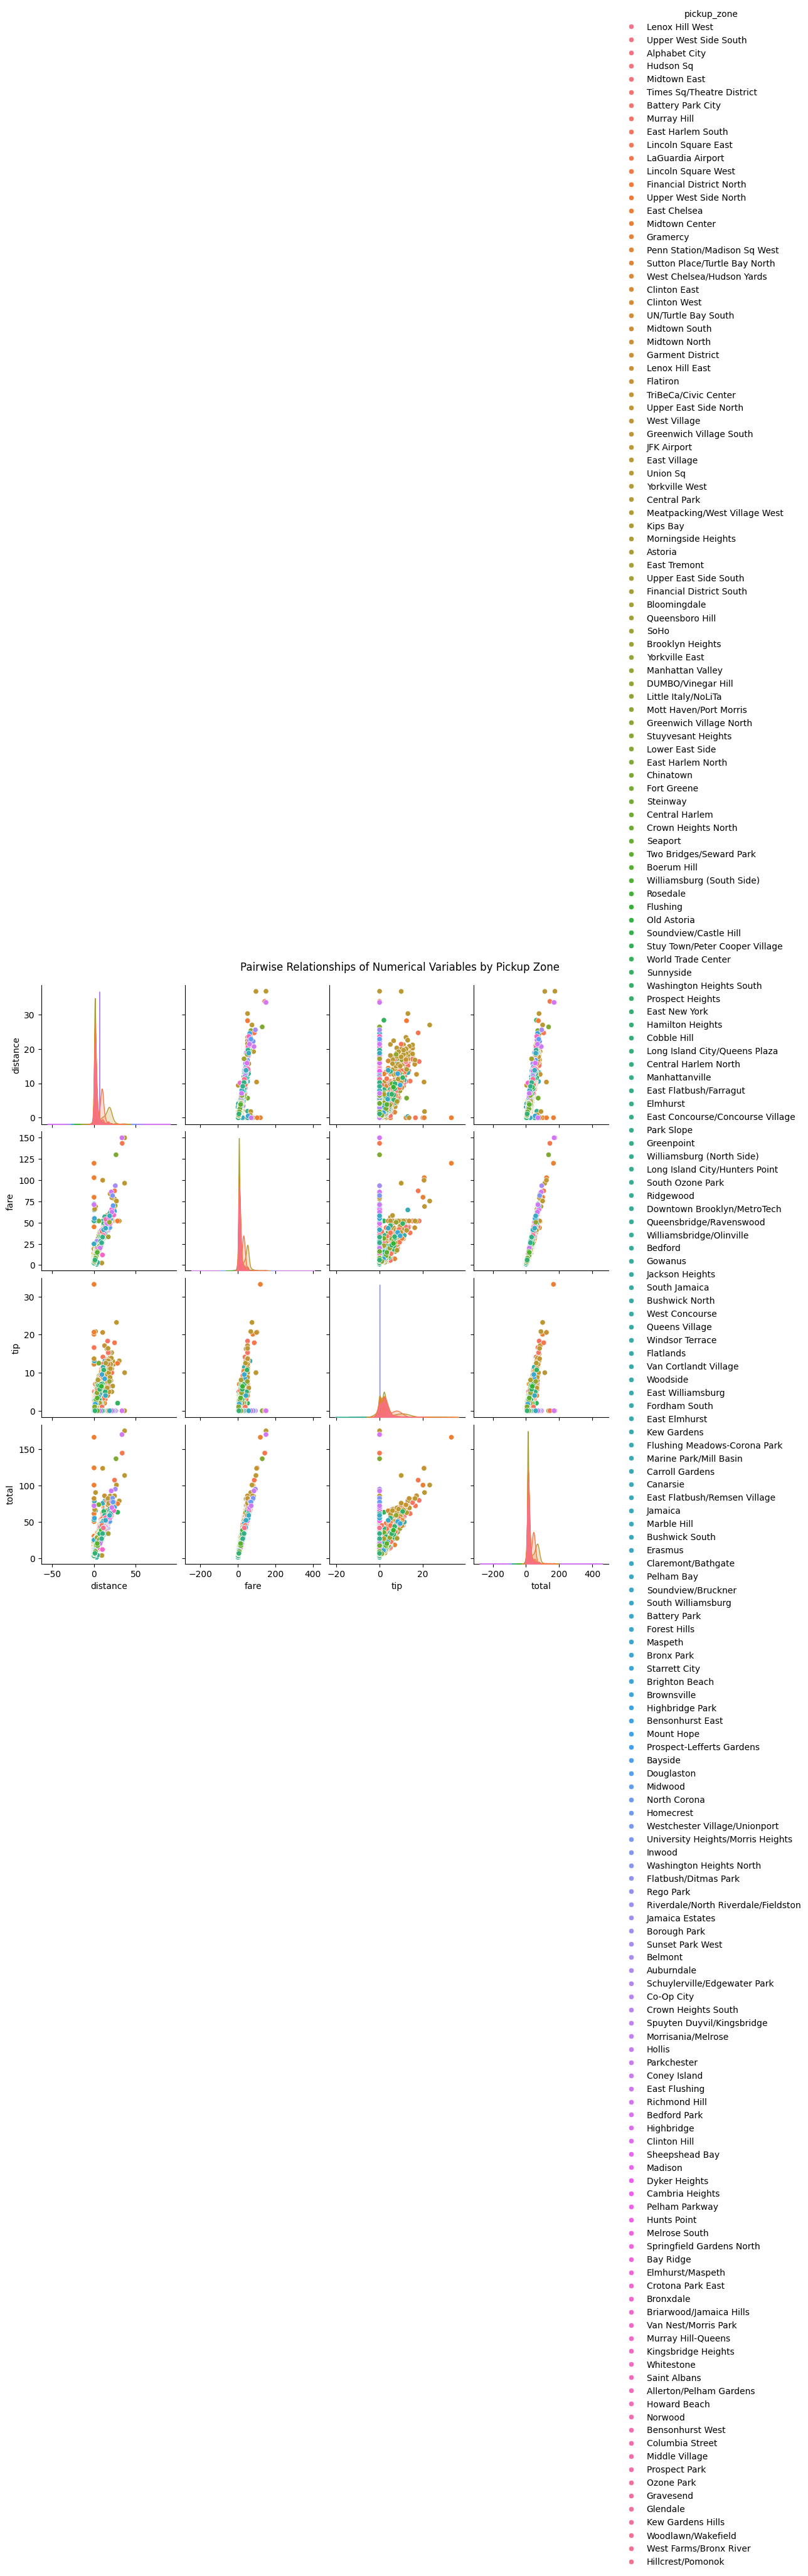

In [31]:
numerical_vars_for_pairplot = ['distance', 'fare', 'tip', 'total']
sns.pairplot(df, vars=numerical_vars_for_pairplot, hue='pickup_zone', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Numerical Variables by Pickup Zone', y=1.02) # Adjust suptitle position
plt.show()

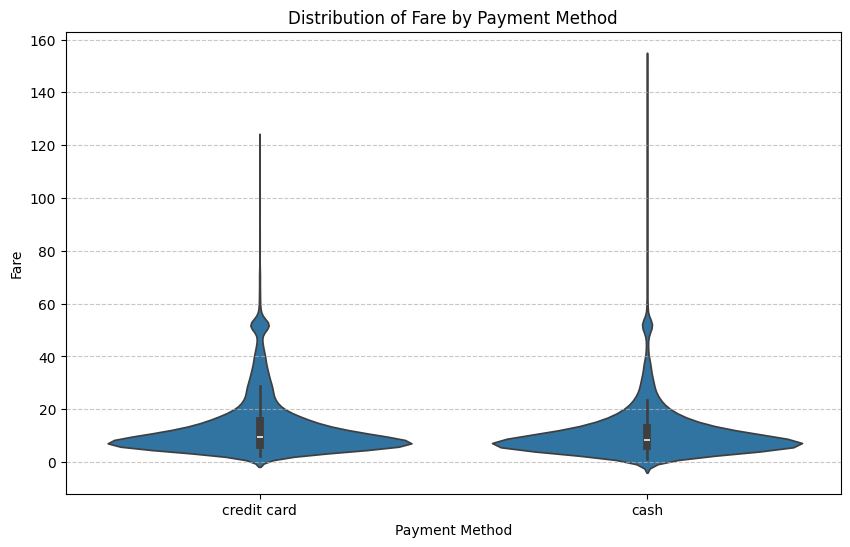

In [32]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='payment', y='fare', data=df)
plt.title('Distribution of Fare by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()